# Flu phase vs. model annual cycle

External validation: does the trolley model's annual cycle peak align with the empirical flu peak week?

- **Empirical**: pool weekly flu cases across all seasons (W40 → W20 next year), take peak week + shortest contiguous 95% window.
- **Model**: from posterior draws of `beta`, `gamma` in v1.1 and v2.7, derive peak week `t* = (52/(2π)) · atan2(gamma, beta) mod 52`.
- **Compare**: overlay per-region model posterior `t*` (both versions) on the empirical 95% window.

Both models share the same annual harmonic structure (`beta·cos + gamma·sin`); v2.7 additionally fits NY indicators and a 5-week MW event but those terms don't shift the harmonic phase.

In [26]:
import subprocess
from pathlib import Path
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from IPython.display import Image, display

ROOT = Path('..').resolve()
MODEL_DIR = ROOT / 'data/models/wide_weekly_scaledPer10k/v1.1'
LOCAL_FLU_CSV = ROOT / 'supplementary data/Respiratory_Virus_Hub_Open_Data.csv'

FEATURE_SERVICE = (
    'https://services3.arcgis.com/dQsP3byyKkTT53Ep/arcgis/rest/services/'
    'flat_extract_weekly_resp/FeatureServer/0/query'
)

# --- table-render helpers, same pattern as May_Presentation/slide_tables.ipynb ---
TABLES_DIR = ROOT / 'May_Presentation' / 'tables'
RENDERED   = TABLES_DIR / 'rendered'
RENDERED.mkdir(parents=True, exist_ok=True)

PREAMBLE = r'''\documentclass[varwidth=24cm,border=14pt]{standalone}
\usepackage{booktabs, siunitx}
\sisetup{table-format=4.1, group-separator={,}}
\begin{document}
'''
POSTAMBLE = r'''
\end{document}
'''
LATEXMK = '/opt/homebrew/bin/latexmk'

def render_table(name, body):
    tex_path = TABLES_DIR / f'{name}.tex'
    tex_path.write_text(PREAMBLE + body + POSTAMBLE)
    res = subprocess.run(
        [LATEXMK, '-cd', '-pdf', '-interaction=nonstopmode', str(tex_path)],
        capture_output=True, text=True,
    )
    if res.returncode != 0:
        print('STDOUT:', res.stdout[-2000:])
        print('STDERR:', res.stderr[-2000:])
        raise RuntimeError(f'latexmk failed for {name}')
    display(Image(str(RENDERED / f'{name}.png')))

## 1. Fetch latest HPSC weekly respiratory data

Live pull from `flat_extract_weekly_resp` (national, weekly, 2017 W40 → present). Falls back to the local CSV if the request fails.

In [27]:
def fetch_hpsc_weekly():
    params = {'where': '1=1', 'outFields': '*', 'f': 'json', 'resultRecordCount': 32000}
    r = requests.get(FEATURE_SERVICE, params=params, timeout=30)
    r.raise_for_status()
    feats = r.json()['features']
    df = pd.DataFrame([f['attributes'] for f in feats])
    df['floor'] = pd.to_datetime(df['floor'], unit='ms')
    df['ceiling'] = pd.to_datetime(df['ceiling'], unit='ms')
    return df

try:
    flu_all = fetch_hpsc_weekly()
    source = 'live HPSC feature service'
except Exception as e:
    print('live fetch failed, falling back to local CSV:', e)
    flu_all = pd.read_csv(LOCAL_FLU_CSV, encoding='utf-8-sig')
    flu_all['floor'] = pd.to_datetime(flu_all['floor'])
    flu_all['ceiling'] = pd.to_datetime(flu_all['ceiling'])
    source = 'local CSV'

flu = flu_all[flu_all['disease'] == 'Influenza'].copy().sort_values('floor').reset_index(drop=True)
flu['iso_year'] = flu['floor'].dt.isocalendar().year.astype(int)
flu['iso_week'] = flu['floor'].dt.isocalendar().week.astype(int)
print(f'source: {source}')
print(f'rows: {len(flu)},  range: {flu["floor"].min().date()} → {flu["floor"].max().date()}')
flu[['floor', 'iso_year', 'iso_week', 'weekly_cases']].head()

live fetch failed, falling back to local CSV: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
source: local CSV
rows: 449,  range: 2017-10-01 → 2026-05-03


,floor,iso_year,iso_week,weekly_cases
0,2017-10-01 00:00:00+00:00,2017,39,5
1,2017-10-08 00:00:00+00:00,2017,40,11
2,2017-10-15 00:00:00+00:00,2017,41,8
3,2017-10-22 00:00:00+00:00,2017,42,13
4,2017-10-29 00:00:00+00:00,2017,43,3


## 2. Per-season peak week + 95% HDR

Season `s` = ISO weeks 40 of year `s` → week 20 of year `s+1`. HDR = smallest contiguous block of weeks whose `weekly_cases` mass covers ≥ 95% of the season total.

In [28]:
def assign_season(row):
    y, w = int(row['iso_year']), int(row['iso_week'])
    if w >= 40:
        return y
    if w <= 20:
        return y - 1
    return np.nan

flu['season'] = flu.apply(assign_season, axis=1)
flu_season = flu.dropna(subset=['season']).copy()
flu_season['season'] = flu_season['season'].astype(int)

def woy_centered(w):
    w = np.asarray(w, dtype=int)
    return np.where(w >= 40, w - 53, w)

flu_season['woy_c'] = woy_centered(flu_season['iso_week'].values)

def contiguous_hdr(weeks, mass, level=0.95):
    """Smallest contiguous window of `weeks` whose `mass` covers >= level of total."""
    order = np.argsort(weeks)
    w, m = np.asarray(weeks)[order], np.asarray(mass)[order]
    target = level * m.sum()
    n = len(w)
    best = (None, None, n + 1)
    for i in range(n):
        cum = 0.0
        for j in range(i, n):
            cum += m[j]
            if cum >= target:
                if (j - i) < best[2]:
                    best = (w[i], w[j], j - i)
                break
    return best[0], best[1]

rows = []
for s, grp in flu_season.groupby('season'):
    if grp['weekly_cases'].sum() == 0:
        continue
    grp = grp.sort_values('woy_c')
    lo, hi = contiguous_hdr(grp['woy_c'].values, grp['weekly_cases'].values, level=0.95)
    peak_idx = grp['weekly_cases'].idxmax()
    rows.append({
        'season': s,
        'season_label': f'{s}/{s+1}',
        'total_cases': int(grp['weekly_cases'].sum()),
        'peak_woy_c': int(grp.loc[peak_idx, 'woy_c']),
        'peak_iso_week': int(grp.loc[peak_idx, 'iso_week']),
        'hdr_lo': int(lo),
        'hdr_hi': int(hi),
        'hdr_width': int(hi - lo + 1),
    })
season_summary = pd.DataFrame(rows).sort_values('season').reset_index(drop=True)
season_summary

,season,season_label,total_cases,peak_woy_c,peak_iso_week,hdr_lo,hdr_hi,hdr_width
0,2017,2017/2018,11823,1,1,-3,14,18
1,2018,2018/2019,7994,6,6,-4,15,20
2,2019,2019/2020,11117,1,1,-5,12,18
3,2021,2021/2022,2216,11,11,5,18,14
4,2022,2022/2023,15997,-1,52,-10,13,24
5,2023,2023/2024,16629,-1,52,-6,16,23
6,2024,2024/2025,27175,-1,52,-6,15,22
7,2025,2025/2026,24876,-3,50,-10,6,17


## 2b. Averaged season — naive pool

Pool weekly flu cases across all seasons by week-of-year (centred), then take peak and contiguous 95% window.

- Each week-of-season gets one total: sum of `weekly_cases` across every season at that week
- No per-season normalisation — heavy flu years carry more weight (that's the "naive" part)
- Peak = week with max pooled count; 95% window = shortest contiguous run of weeks holding ≥ 95% of pooled mass

In [29]:
weeks_axis = np.arange(-13, 21)  # W40..W52 -> -13..-1, W1..W20 -> 1..20

# pool weekly cases across every season at each week-of-season
pooled = (flu_season.groupby('woy_c')['weekly_cases'].sum()
          .reindex(weeks_axis, fill_value=0))

peak_woy = int(pooled.idxmax())
hdr_lo, hdr_hi = contiguous_hdr(pooled.index.values, pooled.values, level=0.95)

mean_view = {
    'n_seasons': int(flu_season['season'].nunique()),
    'peak_woy_c': peak_woy,
    'hdr_lo': int(hdr_lo),
    'hdr_hi': int(hdr_hi),
    'pooled': pooled,
}

pd.DataFrame([{
    'view': 'all (pooled)',
    'n_seasons': mean_view['n_seasons'],
    'peak_woy_c': mean_view['peak_woy_c'],
    'hdr_lo': mean_view['hdr_lo'],
    'hdr_hi': mean_view['hdr_hi'],
    'hdr_width': mean_view['hdr_hi'] - mean_view['hdr_lo'] + 1,
}])

,view,n_seasons,peak_woy_c,hdr_lo,hdr_hi,hdr_width
0,all (pooled),9,-1,-9,13,23


## 3. Empirical phase plot

Each row = one flu season. Bar = 95% HDR (in centred week-of-year, W40 = -12 ... W20 = 20). Dot = peak week.

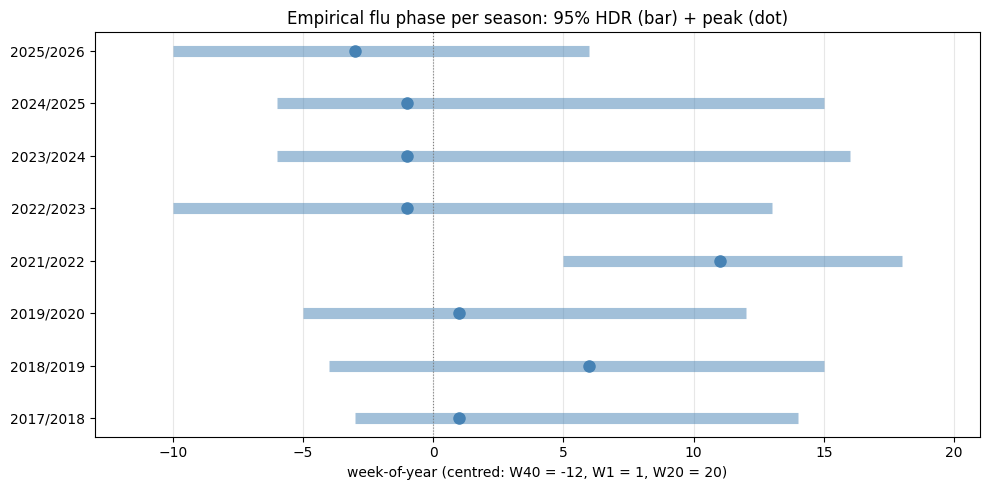

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, r in season_summary.iterrows():
    ax.hlines(i, r['hdr_lo'], r['hdr_hi'], color='steelblue', lw=8, alpha=0.5)
    ax.plot(r['peak_woy_c'], i, 'o', color='steelblue', markersize=8)
ax.set_yticks(range(len(season_summary)))
ax.set_yticklabels(season_summary['season_label'])
ax.set_xlabel('week-of-year (centred: W40 = -12, W1 = 1, W20 = 20)')
ax.set_title('Empirical flu phase per season: 95% HDR (bar) + peak (dot)')
ax.axvline(0, color='grey', ls=':', lw=0.8)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(-13, 21)
plt.tight_layout()
plt.show()

## 4. Model cycle phase posterior (v1.1)

For each region `i`, posterior peak time `t*_i = (52 / (2π)) · atan2(γ_i, β_i) mod 52`.
Map `t*` to ISO week-of-year using t=1 ≡ ISO wk 1, then to the centred axis.

In [31]:
MODEL_DIRS = {
    'v1.1': ROOT / 'data/models/wide_weekly_scaledPer10k/v1.1',
    'v2.7': ROOT / 'data/models/wide_weekly_scaledPer10k/v2.7',
}
regions = ['HSE Dublin and Midlands', 'HSE Dublin and North East', 'HSE Dublin and South East',
           'HSE Mid West', 'HSE South West', 'HSE West and North West']

def peak_t_mod52(beta_draws, gamma_draws):
    t = (52.0 / (2 * np.pi)) * np.arctan2(gamma_draws, beta_draws)
    return t % 52

def compute_phase(samples, regions, model_label):
    rows = []
    for i, region in enumerate(regions, start=1):
        b = samples[f'beta[{i}]'].values
        g = samples[f'gamma[{i}]'].values
        R = np.sqrt(b**2 + g**2)
        t_star = peak_t_mod52(b, g)
        woy_c = np.where(t_star >= 40, t_star - 53, t_star)
        rows.append({
            'model': model_label,
            'region': region,
            'amp_median': float(np.median(R)),
            'median_woy_c': float(np.median(woy_c)),
            'lo_woy_c':  float(np.quantile(woy_c, 0.025)),
            'hi_woy_c':  float(np.quantile(woy_c, 0.975)),
            'draws': woy_c,
        })
    return pd.DataFrame(rows)

phase_df = pd.concat(
    [compute_phase(pd.read_csv(d / 'raw_samples.csv'), regions, v)
     for v, d in MODEL_DIRS.items()],
    ignore_index=True,
)
phase_df[['model', 'region', 'amp_median', 'lo_woy_c', 'median_woy_c', 'hi_woy_c']]

,model,region,amp_median,lo_woy_c,median_woy_c,hi_woy_c
0,v1.1,HSE Dublin and Midlands,0.800963,0.031190,6.361917,12.663846
1,v1.1,HSE Dublin and North East,0.673565,-3.817691,1.797240,6.568341
2,v1.1,HSE Dublin and South East,0.736370,-3.778395,2.101962,7.141890
3,v1.1,HSE Mid West,0.779572,-2.936284,18.898694,33.895181
4,v1.1,HSE South West,1.139033,-3.861415,2.701359,8.509099
5,v1.1,HSE West and North West,0.705244,-7.811322,5.798235,25.803854
6,v2.7,HSE Dublin and Midlands,0.845974,0.234335,5.729431,11.300075
7,v2.7,HSE Dublin and North East,0.681485,-3.364548,1.723468,5.950051
8,v2.7,HSE Dublin and South East,0.773404,-3.554921,1.945589,6.545945
9,v2.7,HSE Mid West,0.646028,-6.902883,20.241389,36.024382


## 5. Overlay: model `t*` vs empirical HDRs

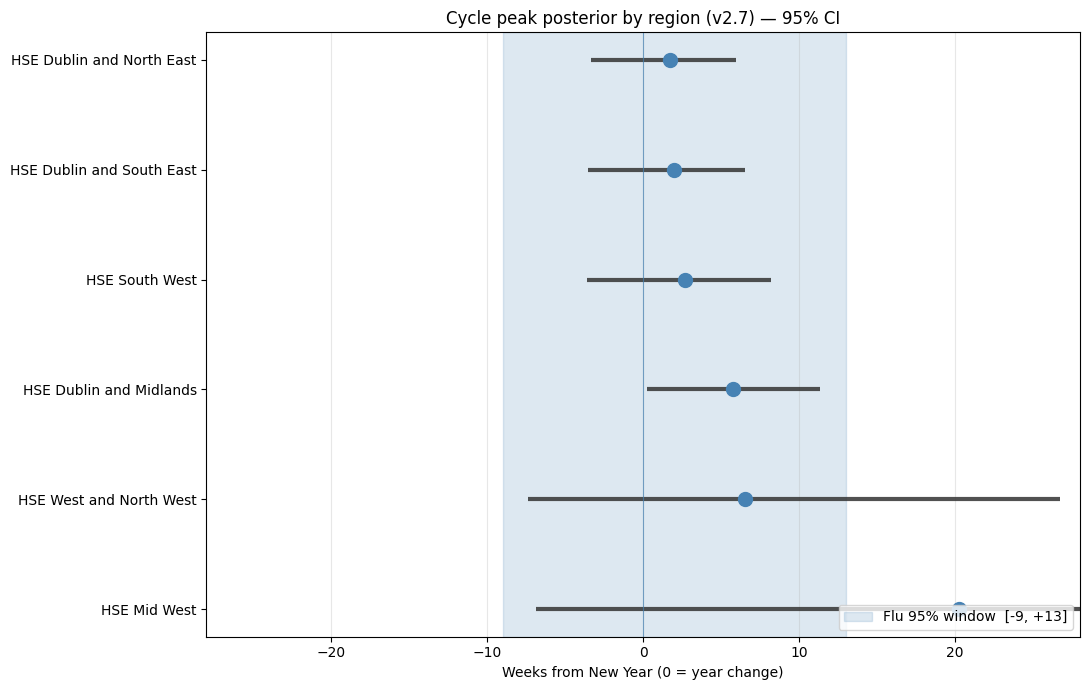

In [32]:
fig, ax = plt.subplots(figsize=(11, 7))

# v2.7 only
sub = (phase_df[phase_df['model'] == 'v2.7']
       .sort_values('median_woy_c', ascending=False)
       .reset_index(drop=True))

# highlighted band: empirical flu 95% window (pooled across all seasons)
ax.axvspan(mean_view['hdr_lo'], mean_view['hdr_hi'], alpha=0.18, color='steelblue',
           label=f"Flu 95% window  [{mean_view['hdr_lo']:+d}, {mean_view['hdr_hi']:+d}]")

for j, row in sub.iterrows():
    ax.hlines(j, row['lo_woy_c'], row['hi_woy_c'],
              color='#333333', lw=3, alpha=0.85)
    ax.plot(row['median_woy_c'], j, 'o',
            color='steelblue', markersize=10,
            markeredgecolor='steelblue', zorder=5)

ax.set_yticks(range(len(sub)))
ax.set_yticklabels(sub['region'], fontsize=10)
ax.set_xlabel('Weeks from New Year (0 = year change)')
ax.set_title('Cycle peak posterior by region (v2.7) — 95% CI')
ax.axvline(0, color='steelblue', lw=0.8, alpha=0.7)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(-28, 28)
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

## Notes / open questions

- COVID-era seasons (2020/21, 2021/22) are kept in; flag them visually next iteration.
- Using **lab-confirmed cases**. Live feature service also exposes `weekly_hospitalised` — swap in to check robustness.
- v1.1 is region-level; same national flu curve compared against 6 regional `t*` posteriors — dispersion across regions = honest evidence for/against regional homogeneity.
- HDR is over weeks-as-bins (no smoothing). For a peaked unimodal series this is fine; if multi-modal (rare) the contiguous-window assumption breaks.